# What role does the graph play in the MEAN-DEGREE model?

The mean-degree normalization couples every edge at the same strength, $\alpha_{ij}=\mu/C_{\rm eff}+(\sigma/\sqrt{C_{\rm eff}})z_{ij}$,
so unlike own-degree it does NOT cancel degree out of the field: a firm's field variance is
$\propto k_i/C$. If the graph matters anywhere in this family, it should be here.

Same design as `graph_role.ipynb` §3 but mean-degree normalization, $N=8000$ (sub-8k numbers
mislead), and the **quenched** estimator (per-economy fits, then average) throughout:

| topology | degree CV | tail | role |
|---|---|---|---|
| `regular` | 0 | none | no-heterogeneity control at matched dilution $C/N=1/40$ |
| `exponential` | ~1 | light | finite-variance heterogeneity |
| `pl3.5` | moderate | power law, finite variance | |
| `pl2.5` | large | power law, infinite variance | the thesis graph |
| `fc` | 0 | none | $C=N$ endpoint: no heterogeneity AND no dilution |

Note `fc` differs from `regular` in dilution (1 vs 1/40), so regular-vs-fc isolates dilution and
regular-vs-pl2.5 isolates heterogeneity.

Observables per topology, 20 economies each: per-economy $\beta$, quenched $\zeta_q$ ratios,
per-economy tent excess kurtosis, survival.

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
import networkx as nx
from scipy import sparse
from scipy.stats import laplace
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate
from relative_glv.msb import size_volatility, tent_stats, rescale

MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N, C = 8000, 200                                    # C = N/40, the C∝N operating point
SEEDS = 20
TMAX, N_EVAL, LATE, DT = 250.0, 700, (180.0, 240.0), 0.5
NB, NJOBS = 20, int(os.environ.get("MC_NJOBS", 6))
TOPOS = ["regular", "exponential", "pl2.5", "pl3.5", "fc"]
print(f"mean-degree topology sweep  N={N} C={C}  {SEEDS} seeds x {TOPOS}  njobs={NJOBS}")

mean-degree topology sweep  N=8000 C=200  20 seeds x ['regular', 'exponential', 'pl2.5', 'pl3.5', 'fc']  njobs=6


In [2]:
# ---- builders + quenched estimators (mirrors graph_role.ipynb helpers) ------------------------

def degree_seq(topo, N, rng):
    """Degree sequence with mean ~C; topologies differ only in tail / variance."""
    if topo == "regular":
        return np.full(N, C, float)
    if topo == "exponential":
        return np.maximum(rng.exponential(C, N), 1.0)
    a = 2.5 if topo == "pl2.5" else 3.5
    kmin = C * (a - 2) / (a - 1)
    return np.maximum(kmin * (1 - rng.uniform(size=N)) ** (-1 / (a - 1)), 1.0)

def meandeg_alpha(topo, N, mu, sigma, seed):
    """MEAN-DEGREE couplings on an arbitrary degree distribution: every directed edge gets
    mu/C_eff + (sigma/sqrt(C_eff)) z, z iid (statistically identical to coupling(kind='powerlaw')
    at gamma=0, generalized to the other degree sequences)."""
    rng = np.random.default_rng(seed)
    deg = np.maximum(np.round(degree_seq(topo, N, rng)).astype(int), 1)
    if deg.sum() % 2:
        deg[deg.argmin()] += 1
    G = nx.Graph(nx.configuration_model(deg.tolist(), seed=int(seed)))
    G.remove_edges_from(nx.selfloop_edges(G))
    A = nx.to_scipy_sparse_array(G, format="csr", dtype=float)
    ki = np.diff(A.indptr).astype(float); ki[ki == 0] = 1.0
    C_eff = float(ki.mean())
    coo = A.tocoo()
    z = rng.normal(size=coo.row.size)
    vals = mu / C_eff + (sigma / np.sqrt(C_eff)) * z
    return sparse.csr_array((vals, (coo.row, coo.col)), shape=(N, N)), ki

def cq_one(S, v, nb=NB):
    """zeta_1..4 for ONE economy on its OWN decline branch — the pooling-free estimator."""
    live = (v > 0) & np.isfinite(v) & (S > 0)
    S, v = S[live], v[live]
    if S.size < 200:
        return None
    o = np.argsort(S); P = np.array_split(np.arange(o.size), nb)
    bx = np.array([S[o][p].mean() for p in P]); by = np.array([np.median(v[o][p]) for p in P])
    m = (bx > 0) & (by > 0); bx, by = bx[m], by[m]
    pk = int(np.argmax(by)); dec = S > bx[pk]; nfit = max(6, nb - pk)
    if dec.sum() < 200:
        return None
    Sx, vx = S[dec], v[dec]
    ox = np.argsort(Sx); Px = np.array_split(np.arange(ox.size), nfit)
    bxx = np.array([Sx[ox][p].mean() for p in Px]); out = []
    for q in (1, 2, 3, 4):
        byy = np.array([np.mean(vx[ox][p] ** q) for p in Px])
        mm = (bxx > 0) & (byy > 0)
        if mm.sum() < 3:
            return None
        out.append(-np.polyfit(np.log10(bxx[mm]), np.log10(byy[mm]), 1)[0])
    c = np.array(out)
    return c if c[0] > 0 else None

In [3]:
def run_topo(topo, seed):
    """One economy -> per-survivor size/vol/growth, or None if it froze/failed."""
    if topo == "fc":
        alpha = coupling(N, MU, SIGMA, kind="fc", seed=seed)
        ki = np.full(N, N - 1, float)
    else:
        alpha, ki = meandeg_alpha(topo, N, MU, SIGMA, seed)
    r = integrate(alpha, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    sv = size_volatility(r["W"], r["t"], window=LATE, dt=DT, n_bins=NB)
    if sv["growth"].size == 0 or not np.isfinite(sv["beta"]):
        return None
    return dict(topo=topo, seed=seed, Sbar=sv["Sbar"], vol=sv["vol"], growth=sv["growth"],
                beta=float(sv["beta"]), exk=float(tent_stats(sv["growth"])["exkurt"]),
                kcv=float(ki.std() / ki.mean()))

t0 = time.time()
jobs = [(t, s) for t in TOPOS for s in range(SEEDS)]
out = [x for x in Parallel(n_jobs=NJOBS, backend="loky")(
    delayed(run_topo)(t, s) for t, s in jobs) if x is not None]
print(f"integrated in {(time.time()-t0)/60:.1f} min; {len(out)}/{len(jobs)} economies survived\n")

D = dict(N=N, C=C, seeds=SEEDS, topos=np.array(TOPOS))
print(f"{'topology':<12}{'surv':>6}{'CV(k)':>8}{'beta':>14}{'quenched zeta_q/zeta_1':>34}{'exk':>12}")
for topo in TOPOS:
    rs = [x for x in out if x["topo"] == topo]
    if len(rs) < 2:
        print(f"{topo:<12}{len(rs):>3}/{SEEDS}  — skipped"); continue
    cqe = np.array([c for c in (cq_one(x["Sbar"], x["vol"]) for x in rs) if c is not None])
    R = cqe / cqe[:, [0]]
    be = np.array([x["beta"] for x in rs]); ek = np.array([x["exk"] for x in rs])
    D[f"{topo}_cq_each"] = cqe; D[f"{topo}_beta_each"] = be; D[f"{topo}_exk_each"] = ek
    D[f"{topo}_ratio_q"] = R.mean(0); D[f"{topo}_ratio_q_err"] = R.std(0) / np.sqrt(R.shape[0])
    D[f"{topo}_kcv"] = float(np.median([x["kcv"] for x in rs]))
    D[f"{topo}_gz"] = rescale(np.vstack([x["growth"] for x in rs]))[::40].astype(np.float32)
    print(f"{topo:<12}{len(rs):>3}/{SEEDS}{D[f'{topo}_kcv']:>8.2f}"
          f"{np.median(be):>9.3f}±{be.std()/np.sqrt(be.size):.3f}"
          f"   {np.round(R.mean(0), 2).tolist()} ± {np.round(R.std(0)/np.sqrt(R.shape[0]), 2).tolist()}"
          f"{np.median(ek):>9.1f}")
print("\nrefs: granular flat [1,1,1,1]   fixed shape [1,2,3,4]   MSB data [1, 2.0, 2.6, 2.9]")
np.savez("data/meandeg_topology.npz", **D)

integrated in 23.2 min; 93/100 economies survived

topology      surv   CV(k)          beta            quenched zeta_q/zeta_1         exk


regular      20/20    0.01    0.943±0.004   [1.0, 1.99, 2.95, 3.87] ± [0.0, 0.0, 0.01, 0.02]     11.3
exponential  13/20    0.95    0.198±0.041   [1.0, 1.95, 2.83, 3.62] ± [0.0, 0.05, 0.15, 0.31]      7.6
pl2.5        20/20    1.54    0.433±0.013   [1.0, 1.86, 2.56, 3.11] ± [0.0, 0.01, 0.02, 0.05]      8.1


pl3.5        20/20    0.69    0.732±0.009   [1.0, 1.93, 2.76, 3.49] ± [0.0, 0.0, 0.01, 0.03]      8.3
fc           20/20    0.00    1.022±0.003   [1.0, 2.0, 3.01, 4.0] ± [0.0, 0.0, 0.0, 0.01]     10.8

refs: granular flat [1,1,1,1]   fixed shape [1,2,3,4]   MSB data [1, 2.0, 2.6, 2.9]


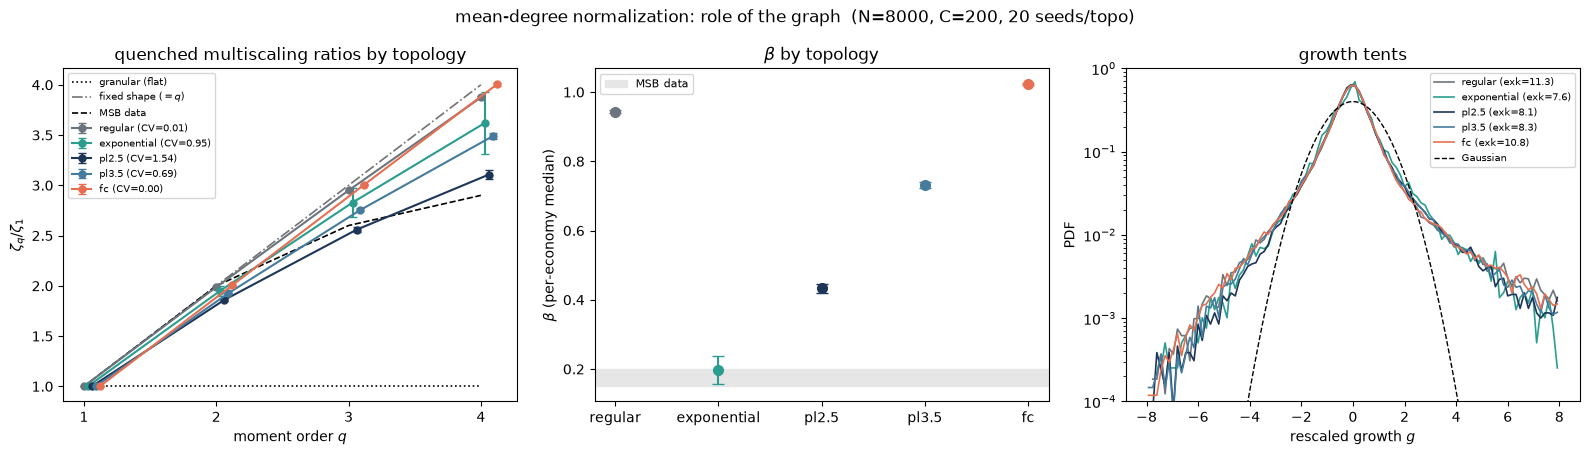

saved data/meandeg_topology.npz and data/meandeg_topology.png


In [4]:
qs = np.array([1, 2, 3, 4])
COLS = {"regular": "#6c757d", "exponential": "#2a9d8f", "pl2.5": "#1d3557",
        "pl3.5": "#457b9d", "fc": "#e76f51"}
HAVE = [t for t in TOPOS if f"{t}_ratio_q" in D]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

for i, t in enumerate(HAVE):
    ax[0].errorbar(qs + 0.03 * i, D[f"{t}_ratio_q"], yerr=D[f"{t}_ratio_q_err"], marker="o",
                   ms=5, capsize=3, color=COLS[t], label=f"{t} (CV={D[f'{t}_kcv']:.2f})")
ax[0].plot(qs, [1, 1, 1, 1], "k:", lw=1.2, label="granular (flat)")
ax[0].plot(qs, qs, "-.", color="0.45", lw=1.2, label=r"fixed shape ($=q$)")
ax[0].plot(qs, [1, 2.0, 2.6, 2.9], "k--", lw=1.2, label="MSB data")
ax[0].set(xlabel="moment order $q$", ylabel=r"$\zeta_q/\zeta_1$", xticks=qs,
          title="quenched multiscaling ratios by topology")
ax[0].legend(fontsize=7)

for i, t in enumerate(HAVE):
    be = D[f"{t}_beta_each"]
    ax[1].errorbar(i, np.median(be), yerr=be.std() / np.sqrt(be.size), marker="o", ms=7,
                   capsize=4, color=COLS[t])
ax[1].axhspan(0.15, 0.20, color="0.9", label="MSB data")
ax[1].set(xticks=range(len(HAVE)), xticklabels=HAVE, ylabel=r"$\beta$ (per-economy median)",
          title=r"$\beta$ by topology")
ax[1].legend(fontsize=8)

zz = np.linspace(-8, 8, 200)
for t in HAVE:
    z = D[f"{t}_gz"]
    h, e = np.histogram(z, bins=100, range=(-8, 8), density=True); m = h > 0
    ax[2].semilogy(0.5 * (e[:-1] + e[1:])[m], h[m], lw=1.2, color=COLS[t],
                   label=f"{t} (exk={np.median(D[f'{t}_exk_each']):.1f})")
ax[2].semilogy(zz, np.exp(-zz ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="Gaussian")
ax[2].set(xlabel=r"rescaled growth $g$", ylabel="PDF", ylim=(1e-4, 1), title="growth tents")
ax[2].legend(fontsize=7)

fig.suptitle(f"mean-degree normalization: role of the graph  (N={N}, C={C}, {SEEDS} seeds/topo)")
plt.tight_layout()
plt.savefig("data/meandeg_topology.png", dpi=120)
plt.show()
print("saved data/meandeg_topology.npz and data/meandeg_topology.png")

## How to read

- **Left:** if the quenched ratio curves coincide across topologies (as they did for own-degree,
  where all sat near the fixed-shape line), the graph does not generate the multiscaling under
  mean-degree either. If `pl2.5` bends below the others toward MSB, degree heterogeneity IS the
  multiscaling mechanism in this normalization — the field variance $\propto k_i/C$ is doing it.
- **Middle:** $\beta$ by topology. Own-degree $\beta$ was topology-invariant; mean-degree's need
  not be — heterogeneity feeds the field. `regular` vs `fc` isolates dilution; `regular` vs
  `pl2.5` isolates heterogeneity.
- **Right:** tent shape by topology (median per-economy excess kurtosis in the legend).

Caveats: single size N=8000 — remember $\beta$ and exkurt drift with N even at fixed topology
(`data/meandeg_beta_vs_N.npz`), so topology *differences* here are meaningful, absolute values are
not. `fc` couplings are $\mu/N,\sigma/\sqrt N$ — the $C=N$ endpoint, not matched dilution.